# Round 1 Exploratory Comparison: OpenIAM and WellClass

This notebook develops a conceptual comparison around OpenIAM `ControlFile_ex2c.yaml` and creates a WellClass representation of a similar layered leakage problem. It is an exploratory model-translation exercise, not a like-for-like numerical comparison. Round 1 deliberately avoids explicit cement plugs so the comparison starts from a shared effective-leakage concept.

## Round 1 Scope

OpenIAM `MultisegmentedWellbore` models leakage as an effective wellbore permeability through layered shale and aquifer segments. SCREEN/WellClass can describe more detailed well construction, but this first round keeps the geometry simple: one vertical conceptual borehole, one casing, one effective leaky annulus, and the OpenIAM stratigraphy. The case is treated as onshore: depth starts at the ground/surface datum, with no seawater column.

## The Three Wellbore Models

OpenIAM offers distinct wellbore abstractions, not progressively detailed versions of a single model. The walkthrough below uses the same sequence for each: explain the model and inputs, stage and run a real control-file example, inspect outputs, then construct a conceptual SCREEN WellClass/Pressure view. The SCREEN views explain setup only; they do not claim numerical equivalence.

| Model | Core abstraction | Typical outputs |
| --- | --- | --- |
| `OpenWellbore` | Drift-flux lookup model for an open conduit | CO2/brine leakage to an aquifer or atmosphere |
| `MultisegmentedWellbore` | 1D Darcy flow through effective layered segments | CO2/brine leakage by aquifer; optional accumulated mass |
| `CementedWellbore` | FEHM-trained reduced-order surrogate | CO2/brine leakage rates and selected cumulative masses |

## Closest SCREEN Concepts (Not Parameter Equivalences)

Every OpenIAM control file still needs a surrounding case: `ModelParams` defines run time, `Stratigraphy` defines the layered system, a reservoir or other source component provides pressure/saturation, and the wellbore component connects to that source and declares outputs. The mappings below are useful for orientation only; they are not one-to-one conversions.

| OpenIAM input or behavior | Nearest SCREEN concept | Why the values are not directly interchangeable |
| --- | --- | --- |
| `Connection` to a reservoir and its pressure/saturation | CIRRUS reservoir/equilibration setup and selected `EQLNUM` region | OpenIAM consumes component signals; SCREEN initializes and solves fields on a grid. |
| `Stratigraphy`, shale/aquifer thicknesses, named leak-to aquifers | WellClass stratigraphy and the coarse vertical grid/layer policy | Layer boundaries and receptor intervals must be aligned explicitly. |
| `OpenWellbore.wellRadius`, `wellTop`, `LeakTo` | Hole/casing geometry, interval depth, and an aquifer/receptor interval | OpenWellbore is a drift-flux conduit model; SCREEN resolves grid materials and fluxes. |
| `OpenWellbore.log*Transmissivity` | No single SCREEN field; possibly effective well-path transmissibility | Transmissivity is not a material `PERMX` value. |
| `MultisegmentedWellbore.logWellPerm` and layer-specific permeability | SCREEN open-hole/cement/barrier material properties | OpenIAM's permeability is an effective 1D segment property; SCREEN assigns 3D cell-region properties. |
| `CementedWellbore.logWellPerm`, `logThiefPerm`, `depthRatio` | SCREEN casing-cement/plug intervals and stratigraphic depths | CementedWellbore is a surrogate with a calibrated training domain and transient pressure/saturation inputs, not explicit cement geometry. |
| OpenIAM leakage-rate outputs by aquifer | Integrated flux from a corresponding SCREEN aquifer/receptor region | The same units do not guarantee identical control surfaces, sign conventions, or time sampling. |

Use these correspondences to design a matched physical scenario. Do not copy a numeric permeability from one model directly into another without defining what physical quantity and flow area it represents.

In [31]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
import yaml

In [32]:
repo_root = Path.cwd()
if not (repo_root / "pyproject.toml").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "pyproject.toml").exists())

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.WellClass.libs.models.well_model import WellModel
from src.WellClass.libs.well_class.well_processed import WellProcessed

openiam_root = repo_root / "work" / "benchmark" / "repos" / "OpenIAM"
openiam_control_file = openiam_root / "examples" / "Control_Files" / "ControlFile_ex2c.yaml"
round1_root = repo_root / "work" / "benchmark" / "cases" / "round1_openiam_screen"
round1_root.mkdir(parents=True, exist_ok=True)

if not openiam_control_file.exists():
    raise FileNotFoundError(f"OpenIAM control file not found: {openiam_control_file}")

openiam_control_file.relative_to(repo_root)

PosixPath('work/benchmark/repos/OpenIAM/examples/Control_Files/ControlFile_ex2c.yaml')

In [33]:
import os
import subprocess
import matplotlib.pyplot as plt

from src.WellClass.libs.well_pressure.pressure import Pressure

openiam_python = openiam_root / ".venv" / "bin" / "python"
openiam_cli = openiam_root / "src" / "openiam" / "components" / "openiam_cf.py"
control_dir = openiam_root / "examples" / "Control_Files"
openiam_environment = os.environ.copy()
openiam_environment.pop("MPLBACKEND", None)

if not openiam_python.is_file():
    raise FileNotFoundError(f"OpenIAM Python environment not found: {openiam_python}")


def control_values(parameters):
    return {key: value.get("value") if isinstance(value, dict) and "value" in value else value for key, value in parameters.items()}


def stratigraphy_intervals(strata_config):
    strata = control_values(strata_config)
    number_of_shales = int(strata["numberOfShaleLayers"])
    layers = []
    for shale_number in range(number_of_shales, 0, -1):
        layers.append((f"shale{shale_number}", float(strata[f"shale{shale_number}Thickness"]), "barrier"))
        aquifer_number = shale_number - 1
        if aquifer_number >= 1:
            layers.append((f"aquifer{aquifer_number}", float(strata[f"aquifer{aquifer_number}Thickness"]), "flow_unit"))
    layers.append(("reservoir", float(strata["reservoirThickness"]), "reservoir"))
    intervals = []
    top_depth = 0.0
    for name, thickness, unit_type in layers:
        bottom_depth = top_depth + thickness
        intervals.append({"name": name, "top_rkb": top_depth, "bottom_rkb": bottom_depth, "unit_type": unit_type})
        top_depth = bottom_depth
    return strata, intervals


def run_openiam_example(control_path, component_name):
    control_path = Path(control_path)
    control = yaml.safe_load(control_path.read_text(encoding="utf-8"))
    result = subprocess.run(
        [str(openiam_python), str(openiam_cli), "--file", str(control_path)],
        cwd=repo_root,
        capture_output=True,
        text=True,
        env=openiam_environment,
    )
    if result.returncode:
        raise RuntimeError(f"{component_name} run failed ({control_path.name}):\n{result.stdout[-1500:]}\n{result.stderr[-1500:]}")
    pattern = Path(control["ModelParams"]["OutputDirectory"])
    output_base = (openiam_root / pattern).resolve()
    output_prefix = output_base.name.split("{", 1)[0]
    output_dirs = sorted(output_base.parent.glob(f"{output_prefix}*"), key=lambda path: path.stat().st_mtime)
    latest_output = output_dirs[-1] if output_dirs else None
    csv_dir = latest_output / "csv_files" if latest_output else None
    csv_files = sorted(path.name for path in csv_dir.glob("*.csv")) if csv_dir and csv_dir.exists() else []
    summary = {
        "component": component_name,
        "control file": control_path.name,
        "end time [years]": control["ModelParams"]["EndTime"],
        "declared outputs": control[component_name].get("Outputs", []),
        "output directory": str(latest_output.relative_to(repo_root)) if latest_output else "not found",
        "result CSV files": csv_files,
        "status": "completed",
    }
    return control, summary


def initial_reservoir_pressure_pa(control, component_name, strata):
    reservoir_parameters = control_values(control["AnalyticalReservoir1"].get("Parameters", {}))
    component_parameters = control_values(control[component_name].get("Parameters", {}))
    for parameters in (component_parameters, reservoir_parameters):
        pressure = float(parameters.get("reservoirInitialPressure", 0.0) or 0.0)
        if pressure > 0:
            return pressure
    pressure = float(reservoir_parameters.get("datumPressure", strata.get("datumPressure", 101325.0)))
    number_of_shales = int(strata["numberOfShaleLayers"])
    for shale_number in range(number_of_shales, 0, -1):
        gradient = float(reservoir_parameters.get(f"shale{shale_number}PressureGrad", reservoir_parameters.get("shalePressureGrad", 9.792e3)))
        pressure += float(strata[f"shale{shale_number}Thickness"]) * gradient
        aquifer_number = shale_number - 1
        if aquifer_number >= 1:
            gradient = float(reservoir_parameters.get(f"aquifer{aquifer_number}PressureGrad", reservoir_parameters.get("aquiferPressureGrad", 9.792e3)))
            pressure += float(strata[f"aquifer{aquifer_number}Thickness"]) * gradient
    return pressure


def plot_openiam_pressure_history(run_summary, label):
    output_dir = repo_root / run_summary["output directory"]
    csv_dir = output_dir / "csv_files"
    pressure_files = sorted(csv_dir.glob("AnalyticalReservoir1_*.pressure.csv"))
    if not pressure_files:
        print(f"No connected-reservoir pressure CSVs found for {label}: {csv_dir}")
        return

    fig, ax = plt.subplots(figsize=(8, 4))
    for csv_path in pressure_files:
        frame = pd.read_csv(csv_path)
        pressure_column = next(column for column in frame.columns if column.endswith(".pressure"))
        location_id = pressure_column.split("_")[-1].split(".")[0]
        ax.plot(frame["Time (days)"] / 365.25, frame[pressure_column] / 1e5, label=f"Reservoir location {location_id}")
    ax.set_title(f"{label}: OpenIAM connected-reservoir pressure history")
    ax.set_xlabel("Time [years]")
    ax.set_ylabel("Pressure [bar]")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()


def build_screen_analogue(control, component_name, label, run_summary=None):
    strata, intervals = stratigraphy_intervals(control["Stratigraphy"])
    component_parameters = control_values(control[component_name].get("Parameters", {}))
    reservoir_parameters = control_values(control["AnalyticalReservoir1"].get("Parameters", {}))
    total_depth = intervals[-1]["bottom_rkb"]
    reservoir_top = next(item["top_rkb"] for item in intervals if item["unit_type"] == "reservoir")
    if control[component_name]["Type"] == "OpenWellbore":
        diameter_in = 2 * float(component_parameters.get("wellRadius", 0.05)) / 0.0254
        well_intervals = [{"name": "Conceptual open conduit", "type": "hole", "top_rkb": 0.0, "bottom_rkb": total_depth, "diameter_in": diameter_in}]
    else:
        log_perm = float(component_parameters.get("logWellPerm", -13.0))
        effective_perm_md = 10**log_perm / 9.869233e-16
        well_intervals = [
            {"name": "Conceptual hole", "type": "hole", "top_rkb": 0.0, "bottom_rkb": total_depth, "diameter_in": 8.5},
            {"name": "Conceptual casing", "type": "casing", "top_rkb": 0.0, "bottom_rkb": total_depth, "diameter_in": 7.0, "shoe": True},
            {"name": "Effective leaky annulus", "type": "casing cement", "top_rkb": 0.0, "bottom_rkb": total_depth, "diameter_in": 7.0, "hc_perm": effective_perm_md},
        ]
    payload = {
        "apiVersion": "well/v0.1",
        "kind": "Well",
        "metadata": {"namespace": "openiam_comparison", "name": label, "author": "screen-openiam-comparison"},
        "spec": {
            "well_header": {"unique_wellbore_identifier": label, "depth_reference_rkb": 0.0, "depth_reference_rkb_unit": "m", "ground_elevation": 0.0, "ground_elevation_unit": "m", "total_depth_rkb": total_depth, "total_depth_rkb_unit": "m"},
            "well_survey": {"md_rkb": [0.0, total_depth], "inclination_deg": [0.0, 0.0], "azimuth_deg": [0.0, 0.0]},
            "hole_casings": well_intervals,
            "plugs": [],
            "stratigraphy": intervals,
        },
    }
    processed = WellProcessed.from_pydantic(WellModel.model_validate(payload))
    pressure_pa = initial_reservoir_pressure_pa(control, component_name, strata)
    pressure = Pressure(
        header=processed.header,
        co2_datum=reservoir_top,
        ground_temperature=4.0,
        geothermal_gradient=31.0,
        rho_brine=float(component_parameters.get("brineDensity", reservoir_parameters.get("brineDensity", 1045.0))),
    )
    scenario = pressure.add_scenario(f"{label}_initial", z_fluid_datum=reservoir_top, p_fluid_datum=pressure_pa / 1e5)
    curves = scenario.display_curves()
    fig, (well_ax, pressure_ax) = plt.subplots(1, 2, figsize=(11, 8), sharey=True)
    processed.plot_sketch(ax=well_ax, draw_geology=True, draw_annotation=True)
    well_ax.set_title(f"{label}: conceptual WellClass well")
    pressure_ax.plot(pressure.table.hydrostatic_pressure, pressure.table.depth, label="Hydrostatic brine")
    pressure_ax.plot(curves["brine_pressure"], curves["brine_depth"], label="Brine with datum offset")
    pressure_ax.plot(curves["fluid_pressure"], curves["fluid_depth"], label="CO2 from initial reservoir datum")
    pressure_ax.plot(pressure.table.min_horizontal_stress, pressure.table.depth, linestyle="--", label="Shmin")
    if control[component_name]["Type"] == "MultisegmentedWellbore" and run_summary is not None:
        output_dir = repo_root / run_summary["output directory"]
        initial_pressure_dir = output_dir / "csv_files" / "MultisegmentedWellbore_Initial_Pressures"
        initial_pressure_files = sorted(initial_pressure_dir.glob(f"{component_name}_*_initial_pressures.csv"))
        for csv_path in initial_pressure_files:
            frame = pd.read_csv(csv_path)
            pressure_column = next(column for column in frame.columns if column.startswith("Initial pressure at datum or bottom"))
            pressure_ax.plot(
                frame[pressure_column] / 1e5,
                frame["Bottom depth (m)"],
                marker="o",
                linestyle="--",
                label="OpenIAM initial pressure at unit bottoms",
            )
        if not initial_pressure_files:
            print(f"No OpenIAM initial-pressure profile found for {label}: {initial_pressure_dir}")
    pressure_ax.axhline(reservoir_top, color="black", linestyle=":", label="Reservoir top")
    pressure_ax.set_title(f"{label}: SCREEN pressure illustration")
    pressure_ax.set_xlabel("Pressure [bar]")
    pressure_ax.set_ylabel("Depth TVDMSL [m]")
    # pressure_ax.invert_yaxis()
    pressure_ax.grid(alpha=0.25)
    pressure_ax.legend()
    fig.tight_layout()
    plt.show()
    if run_summary is not None:
        plot_openiam_pressure_history(run_summary, label)
    print(f"Initial reservoir datum: {pressure_pa / 1e5:.2f} bar at {reservoir_top:.1f} m TVDMSL")
    return processed, pressure, scenario

In [34]:
openiam_case, msw_run_summary = run_openiam_example(openiam_control_file, "msw1")
display(pd.DataFrame([msw_run_summary]))

model_params = openiam_case["ModelParams"]
strata = openiam_case["Stratigraphy"]
reservoir_params = control_values(openiam_case["AnalyticalReservoir1"].get("Parameters", {}))
wellbore_params = control_values(openiam_case["msw1"].get("Parameters", {}))

pd.DataFrame(
    [
        ["run duration [years]", model_params["EndTime"]],
        ["time step [years]", model_params["TimeStep"]],
        ["shale layers", strata["numberOfShaleLayers"]],
        ["default segment log permeability [log10(m^2)]", wellbore_params["logWellPerm"]],
        ["initial reservoir pressure [Pa]", wellbore_params["reservoirInitialPressure"]],
        ["declared outputs", ", ".join(openiam_case["msw1"]["Outputs"])],
    ],
    columns=["input/output", "value"],
)

,component,control file,end time [years],declared outputs,output directory,result CSV files,status
0,msw1,ControlFile_ex2c.yaml,10,"[CO2_aquifer1, brine_aquifer1, CO2_aquifer2, b...",work/benchmark/repos/OpenIAM/output/output_ex2...,"[AnalyticalReservoir1_000.CO2saturation.csv, A...",completed


,input/output,value
0,run duration [years],10
1,time step [years],1.0
2,shale layers,3
3,default segment log permeability [log10(m^2)],-13.5
4,initial reservoir pressure [Pa],6152000.0
5,declared outputs,"CO2_aquifer1, brine_aquifer1, CO2_aquifer2, br..."


## OpenWellbore: Explore Parameters and Boundaries

The upstream component exposes these control-file inputs (ranges/defaults are from its component definition):

| Input | Range or default | SCREEN-adjacent interpretation |
| --- | --- | --- |
| `logReservoirTransmissivity` | -11.27 to -8.40; default -9.83, log10(m^3) | Effective connection from reservoir into the open conduit; not `reservoir_permx`. |
| `logAquiferTransmissivity` | -11.27 to -8.40; default -9.83, log10(m^3) | Effective connection from conduit into the receiving aquifer; not aquifer-cell `PERMX`. |
| `brineSalinity` | 0 to 0.2; default 0.1, mass fraction | Brine property used by the OpenIAM lookup model. |
| `brineDensity` | 900 to 1200 kg/m^3; default 1045 | Used in the optional critical-pressure calculation. |
| `wellRadius` | 0.025 to 0.25 m; default 0.05 | Well radius; analogous to a physical radius derived from SCREEN casing/hole geometry, not an LGR cell size. |
| `wellTop` | 0 to 500 m; default 500 | Top/endpoint depth for the leakage path; normally linked from `LeakTo` and stratigraphy. `LeakTo: atmosphere` sets it to 0 m. |
| `reservoirDepth` | 1000 to 4000 m; default 2000 | Reservoir depth, normally linked from stratigraphy. |
| `critPressure` | 1e5 to 9e7 Pa; no default | Optional user-supplied threshold; only used when both critical-pressure controls are enabled. |

The component also requires a `Connection`, `LeakTo`, and optionally `Number`/`Locations`. `Controls.critPressureApproach` selects threshold-based versus change-from-initial-pressure behavior. `Controls.enforceCritPressure` chooses between a supplied `critPressure` and a calculated threshold using `wellTop`, `reservoirDepth`, and `brineDensity`.

**Pressure boundaries:** `pressure` (Pa) and `CO2saturation` are dynamic inputs linked from the connected component and represent conditions at the well base. The initial pressure is captured from `pressure` at time zero. There is no separate wellhead-pressure input. `LeakTo` selects an aquifer or atmosphere; it is an output destination, not a prescribed wellhead pressure.

**Offshore:** OpenWellbore has no dedicated seawater-column or offshore switch. `LeakTo: atmosphere` explicitly makes the endpoint 0 m, so the included ex4b setup is onshore. An offshore case would need a carefully defined seabed datum, overlying water pressure, stratigraphy, and leakage receptor in the connected system; do not treat the example as offshore-ready without validating that setup.

The next cell makes a copy of `ControlFile_ex4b.yaml` under the ignored `work/` directory. Edit `openwellbore_parameters`, `openwellbore_controls`, or `openwellbore_leak_to`, then run the cell to explore a variant without modifying the upstream example.

In [35]:
openwellbore_source = control_dir / "ControlFile_ex4b.yaml"
openwellbore_config = yaml.safe_load(openwellbore_source.read_text(encoding="utf-8"))
openwellbore_component_name = "OpenWellbore1"
openwellbore_leak_to = "aquifer1"
openwellbore_controls = {
    "critPressureApproach": True,
    "enforceCritPressure": False,
}
openwellbore_parameters = {
    "wellRadius": 0.04,
    "logReservoirTransmissivity": -10.0,
    "logAquiferTransmissivity": -10.0,
    "brineSalinity": 0.0,
    "brineDensity": 1050.0,
}
openwellbore_optional_parameters = {}
component_config = openwellbore_config[openwellbore_component_name]
component_config["LeakTo"] = openwellbore_leak_to
component_config["Controls"] = openwellbore_controls
component_config["Parameters"].update(openwellbore_parameters)
component_config["Parameters"].update(openwellbore_optional_parameters)

exploration_dir = round1_root / "openwellbore_exploration"
exploration_dir.mkdir(parents=True, exist_ok=True)
output_pattern = exploration_dir / "output_openwellbore_{datetime}"
openwellbore_config["ModelParams"]["OutputDirectory"] = os.path.relpath(output_pattern, openiam_root)
openwellbore_control_copy = exploration_dir / "ControlFile_openwellbore_exploration.yaml"
openwellbore_control_copy.write_text(yaml.safe_dump(openwellbore_config, sort_keys=False), encoding="utf-8")

openwellbore_control, openwellbore_run_summary = run_openiam_example(
    openwellbore_control_copy,
    openwellbore_component_name,
)
display(pd.DataFrame([openwellbore_run_summary]))

,component,control file,end time [years],declared outputs,output directory,result CSV files,status
0,OpenWellbore1,ControlFile_openwellbore_exploration.yaml,1,"[CO2_aquifer1, brine_aquifer1]",work/benchmark/cases/round1_openiam_screen/ope...,"[AnalyticalReservoir1_000.CO2saturation.csv, A...",completed


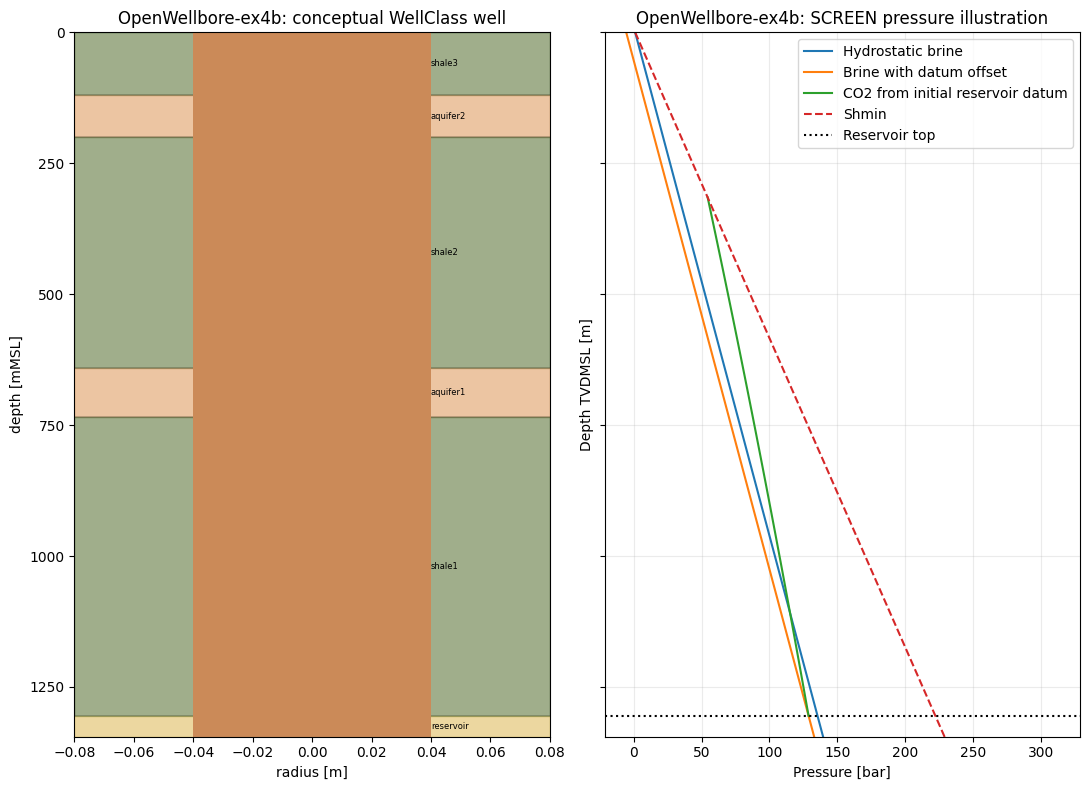

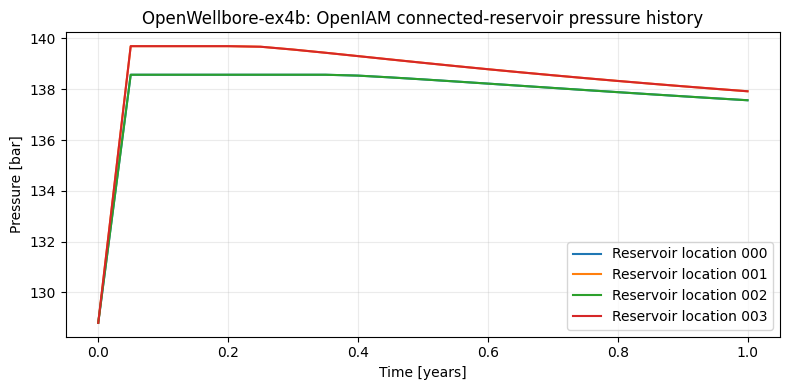

Initial reservoir datum: 128.80 bar at 1305.0 m TVDMSL


In [36]:
openwellbore_well, openwellbore_pressure, openwellbore_scenario = build_screen_analogue(
    openwellbore_control,
    openwellbore_component_name,
    "OpenWellbore-ex4b",
    run_summary=openwellbore_run_summary,
)

### OpenIAM leakage rates by location

OpenIAM writes CO2 and brine leakage rates as separate time series for each OpenWellbore location. These are plotted against time below; they are leakage outputs, not pressure-versus-depth curves. The y-axis keeps the units as OpenIAM output units because the CSV schema does not include a unit field.

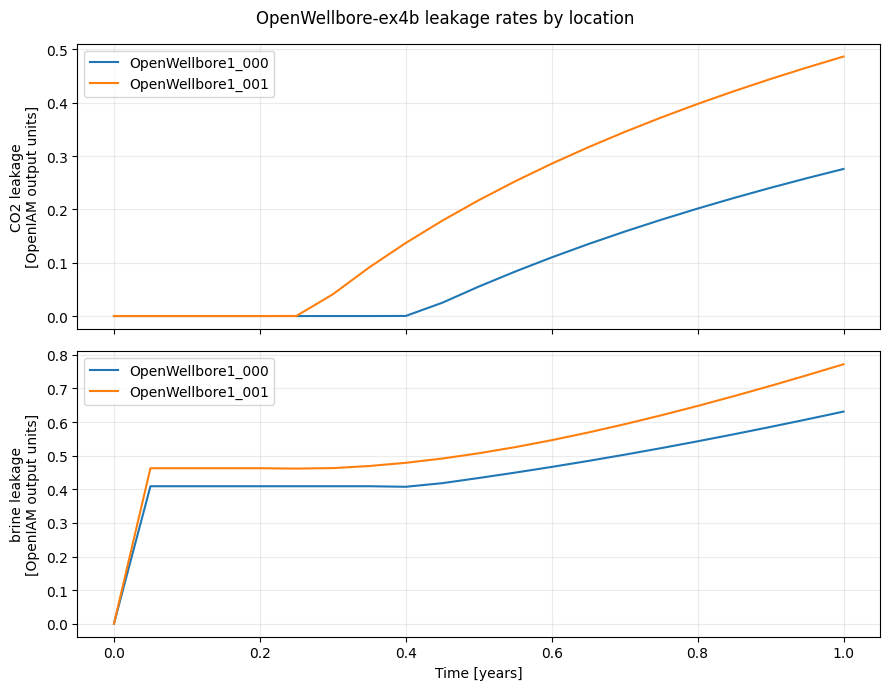

In [45]:
output_dir = repo_root / openwellbore_run_summary["output directory"]
leakage_csv_dir = output_dir / "csv_files"

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for output_kind, axis in [("CO2", axes[0]), ("brine", axes[1])]:
    files = sorted(leakage_csv_dir.glob(f"{openwellbore_component_name}_*.{output_kind}_aquifer*.csv"))
    for csv_path in files:
        frame = pd.read_csv(csv_path)
        value_column = next(column for column in frame.columns if column != "Time (days)")
        location_label = value_column.split(".", 1)[0]
        axis.plot(
            frame["Time (days)"] / 365.25,
            frame[value_column],
            label=location_label,
        )
    axis.set_ylabel(f"{output_kind} leakage\n[OpenIAM output units]")
    axis.grid(alpha=0.25)
    axis.legend()
axes[-1].set_xlabel("Time [years]")
fig.suptitle("OpenWellbore-ex4b leakage rates by location")
fig.tight_layout()
plt.show()

## MultisegmentedWellbore

This model represents leakage through effective 1D segments crossing shale and aquifer layers. Stage `ControlFile_ex2c.yaml` to see its `Stratigraphy`, reservoir connection, per-layer pressure settings, and `logWellPerm` values. `logWellPerm` is an effective segment permeability in `log10(m^2)`, not a SCREEN cell `PERMX`. The model outputs leakage rates by aquifer; accumulation and saved initial pressures are optional controls.

In this example, the well is best understood as a continuous, segmented effective leakage pathway rather than a literal plugged-well geometry. The same `logWellPerm` is used as the default for the modeled well path, so it is conceptually closer to a full-depth impaired cement or annulus pathway with effective permeability. It does not define a localized plug interval with explicit top and bottom depths. A localized SCREEN plug would instead be represented as a depth-specific barrier interval with its own low permeability and would require an explicit mapping into the OpenIAM effective-segment parameters.

In [37]:
openiam_case, msw_run_summary = run_openiam_example(openiam_control_file, "msw1")
display(pd.DataFrame([msw_run_summary]))

model_params = openiam_case["ModelParams"]
strata = control_values(openiam_case["Stratigraphy"])
reservoir_params = control_values(openiam_case["AnalyticalReservoir1"].get("Parameters", {}))
wellbore_params = control_values(openiam_case["msw1"].get("Parameters", {}))

pd.DataFrame(
    [
        ["run duration [years]", model_params["EndTime"]],
        ["time step [years]", model_params["TimeStep"]],
        ["shale layers", strata["numberOfShaleLayers"]],
        ["default segment log permeability [log10(m^2)]", wellbore_params["logWellPerm"]],
        ["initial reservoir pressure [Pa]", wellbore_params["reservoirInitialPressure"]],
        ["declared outputs", ", ".join(openiam_case["msw1"]["Outputs"])],
    ],
    columns=["input/output", "value"],
)

,component,control file,end time [years],declared outputs,output directory,result CSV files,status
0,msw1,ControlFile_ex2c.yaml,10,"[CO2_aquifer1, brine_aquifer1, CO2_aquifer2, b...",work/benchmark/repos/OpenIAM/output/output_ex2...,"[AnalyticalReservoir1_000.CO2saturation.csv, A...",completed


,input/output,value
0,run duration [years],10
1,time step [years],1.0
2,shale layers,3
3,default segment log permeability [log10(m^2)],-13.5
4,initial reservoir pressure [Pa],6152000.0
5,declared outputs,"CO2_aquifer1, brine_aquifer1, CO2_aquifer2, br..."


## Translate OpenIAM Stratigraphy

OpenIAM indexes shale layers upward from the reservoir: `shale1` sits directly above the reservoir. WellClass sketches are easier to inspect top-down, so the translation reverses the order and appends the reservoir at the bottom.

In [38]:
strata, stratigraphy = stratigraphy_intervals(openiam_case["Stratigraphy"])
total_depth_m = stratigraphy[-1]["bottom_rkb"]
reservoir_top_m = next(item["top_rkb"] for item in stratigraphy if item["unit_type"] == "reservoir")
pd.DataFrame(stratigraphy)

,name,top_rkb,bottom_rkb,unit_type
0,shale3,0.0,250.0,barrier
1,aquifer2,250.0,295.0,flow_unit
2,shale2,295.0,545.0,barrier
3,aquifer1,545.0,590.0,flow_unit
4,shale1,590.0,630.0,barrier
5,reservoir,630.0,680.0,reservoir


### SCREEN-side WellProcessed and Pressure view

This creates a conceptual WellClass/Pressure visualization from the ex2c layer stack, effective well permeability, configured brine density, and initial reservoir pressure. The casing/annulus geometry is illustrative; pressure uses SCREEN's constant-density approximation rather than OpenIAM's layer-specific gradients.

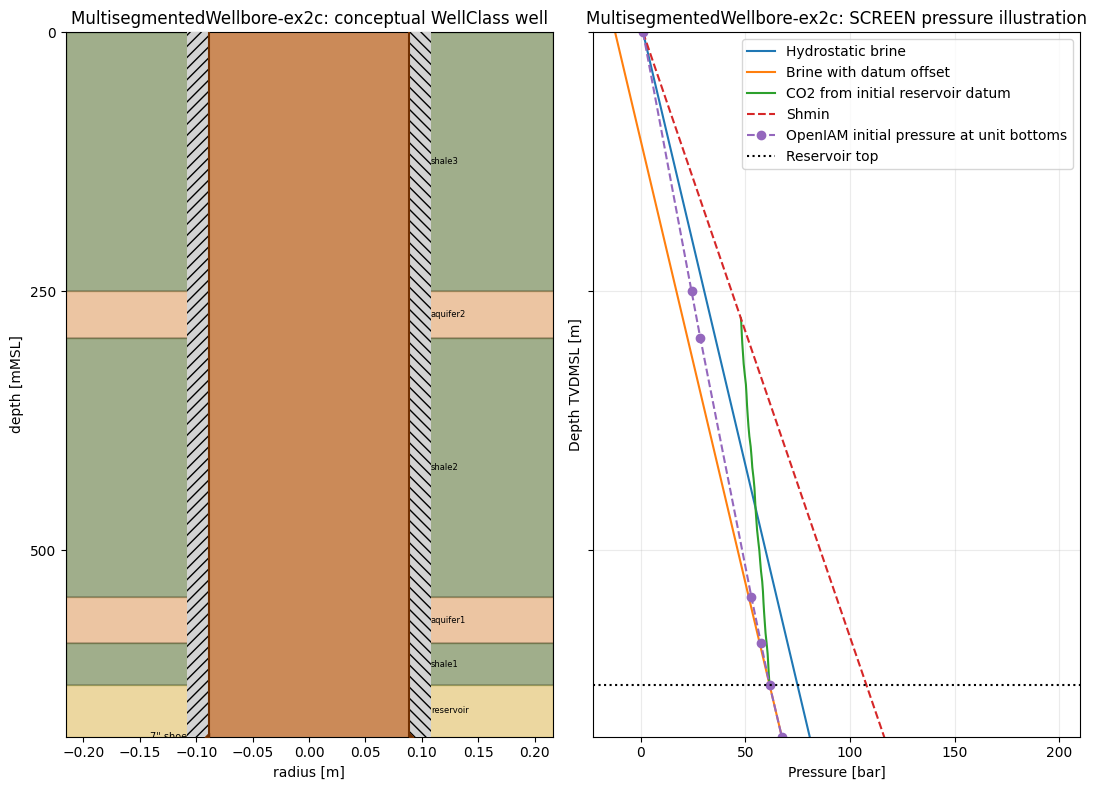

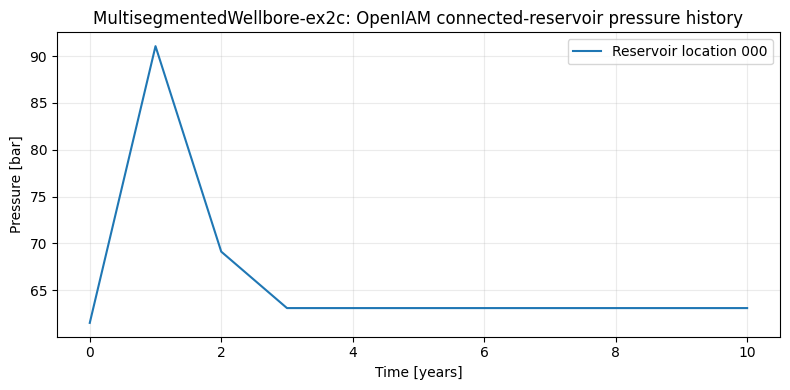

Initial reservoir datum: 61.52 bar at 630.0 m TVDMSL


In [39]:
msw_well, msw_pressure, msw_pressure_scenario = build_screen_analogue(
    openiam_case,
    "msw1",
    "MultisegmentedWellbore-ex2c",
    run_summary=msw_run_summary,
)

## CementedWellbore

This is a reduced-order surrogate trained from detailed FEHM simulations, not a segmented flow-path model. Stage `ControlFile_ex1a.yaml` to inspect `logWellPerm`, `logThiefPerm`, `wellRadius`, and the stratigraphy-linked `wellDepth`/`depthRatio`. Initial pressure and the time-varying pressure/CO2-saturation history come from the connected reservoir; pressure and saturation derivatives are calculated for the surrogate. Its supported training ranges matter: out-of-range cases are not reliable extrapolations.

The SCREEN sketch below is only a conceptual geometry, and its pressure curves use the initial reservoir datum. They do not reproduce the CementedWellbore surrogate's transient inputs or outputs.

In [40]:
cemented_control_path = control_dir / "ControlFile_ex1a.yaml"
cemented_control, cemented_run_summary = run_openiam_example(cemented_control_path, "CementedWellbore1")
display(pd.DataFrame([cemented_run_summary]))

cemented_parameters = control_values(cemented_control["CementedWellbore1"].get("Parameters", {}))
display(pd.DataFrame(
    [[key, value] for key, value in cemented_parameters.items()] +
    [["connected reservoir outputs", ", ".join(cemented_control["AnalyticalReservoir1"].get("Outputs", []))]],
    columns=["input", "staged value"],
))

,component,control file,end time [years],declared outputs,output directory,result CSV files,status
0,CementedWellbore1,ControlFile_ex1a.yaml,10,"[CO2_aquifer1, CO2_aquifer2, CO2_atm, brine_aq...",work/benchmark/repos/OpenIAM/output/output_ex1...,"[AnalyticalReservoir1_000.CO2saturation.csv, A...",completed


,input,staged value
0,logWellPerm,-13.0
1,connected reservoir outputs,"pressure, CO2saturation"


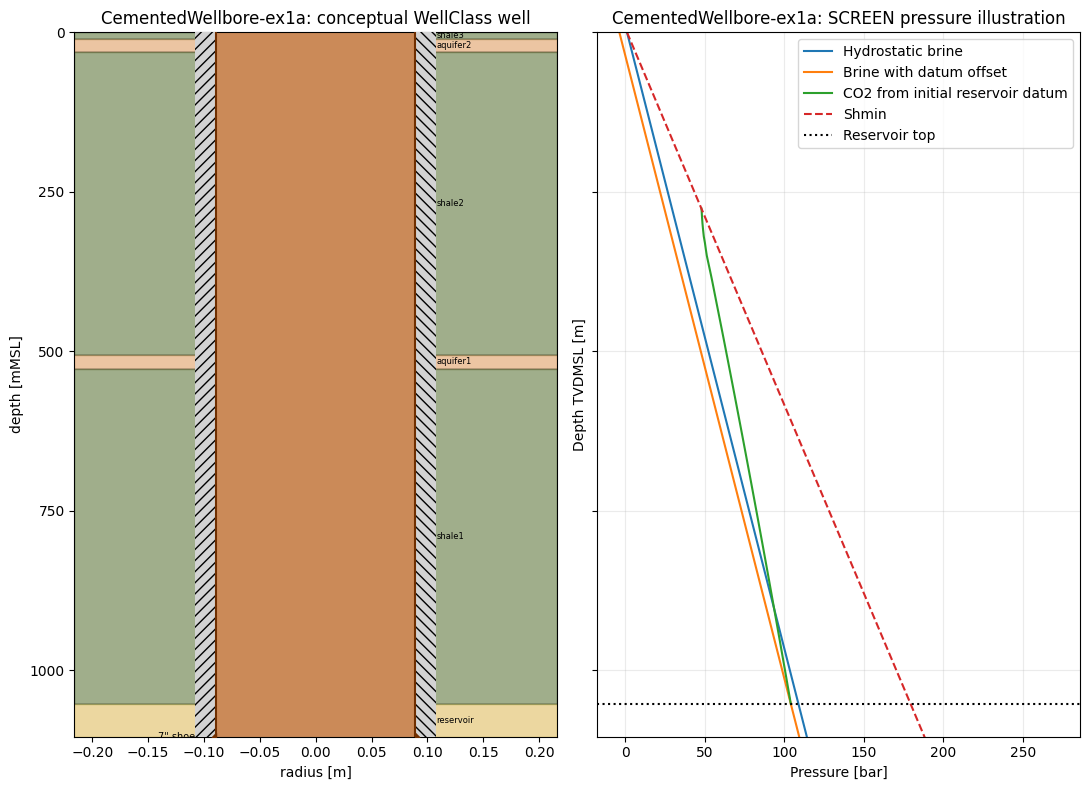

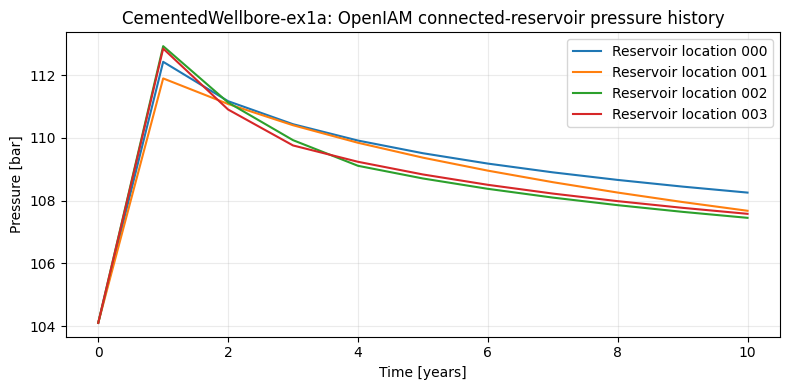

Initial reservoir datum: 104.10 bar at 1052.8 m TVDMSL


In [41]:
cemented_well, cemented_pressure, cemented_pressure_scenario = build_screen_analogue(
    cemented_control,
    "CementedWellbore1",
    "CementedWellbore-ex1a",
    run_summary=cemented_run_summary,
)

### OpenIAM leakage rates for the other wellbore models

The same output view is useful for the `MultisegmentedWellbore` and `CementedWellbore` examples. Their CSV outputs contain leakage rates by model location and receiving aquifer (or atmosphere for the cemented model), rather than pressure-versus-depth data.

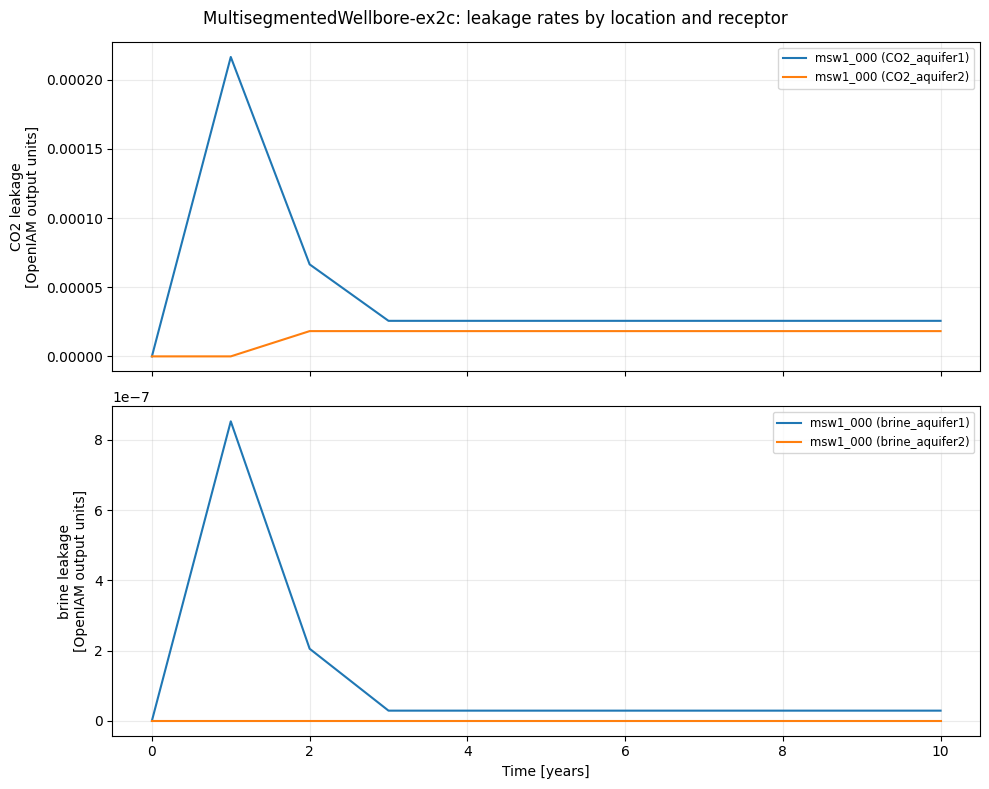

In [46]:
def plot_model_leakage_history(run_summary, component_name, label):
    output_dir = repo_root / run_summary["output directory"]
    csv_dir = output_dir / "csv_files"
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for output_kind, axis in [("CO2", axes[0]), ("brine", axes[1])]:
        files = sorted(csv_dir.glob(f"{component_name}_*.{output_kind}_*.csv"))
        for csv_path in files:
            frame = pd.read_csv(csv_path)
            value_column = next(column for column in frame.columns if column != "Time (days)")
            location_and_target = value_column.split(".", 1)[0]
            target = value_column.split(".", 1)[1]
            axis.plot(frame["Time (days)"] / 365.25, frame[value_column], label=f"{location_and_target} ({target})")
        axis.set_ylabel(f"{output_kind} leakage\n[OpenIAM output units]")
        axis.grid(alpha=0.25)
        axis.legend(fontsize="small")
    axes[-1].set_xlabel("Time [years]")
    fig.suptitle(f"{label}: leakage rates by location and receptor")
    fig.tight_layout()
    plt.show()

plot_model_leakage_history(msw_run_summary, "msw1", "MultisegmentedWellbore-ex2c")

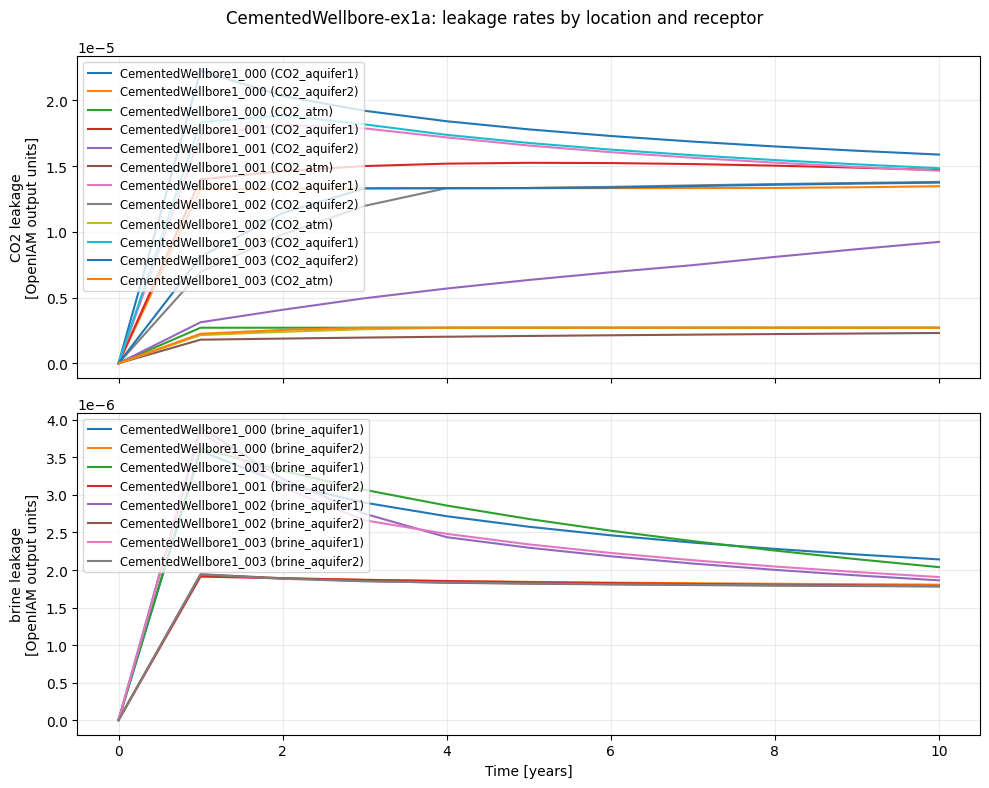

In [47]:
plot_model_leakage_history(
    cemented_run_summary,
    "CementedWellbore1",
    "CementedWellbore-ex1a",
)

## SCREEN and OpenIAM Bridge

These fields are the first-round bridge between the two tools. The comparison should start with effective leakage rates and cumulative leaked mass, not detailed plug performance.

In [42]:
bridge = pd.DataFrame(
    [
        ["stratigraphy", "Stratigraphy shale/aquifer thicknesses", "WellClass stratigraphy intervals"],
        ["leakage permeability", "msw1.Parameters.logWellPerm [log10 m2]", "hole_casings[*].hc_perm [mD] for effective annulus"],
        ["reservoir pressure", "reservoirInitialPressure [Pa]", "SubsurfaceAssumptions p_resrv or p_fluid_contact [bar]"],
        ["run duration", "ModelParams.EndTime [years]", "simulation-years"],
        ["outputs", "CO2_aquifer#, mass_CO2_aquifer#", "CO2 leakage rate and cumulative mass from simulator outputs"],
    ],
    columns=["concept", "OpenIAM ex2c", "SCREEN/WellClass side"],
)
bridge

,concept,OpenIAM ex2c,SCREEN/WellClass side
0,stratigraphy,Stratigraphy shale/aquifer thicknesses,WellClass stratigraphy intervals
1,leakage permeability,msw1.Parameters.logWellPerm [log10 m2],hole_casings[*].hc_perm [mD] for effective ann...
2,reservoir pressure,reservoirInitialPressure [Pa],SubsurfaceAssumptions p_resrv or p_fluid_conta...
3,run duration,ModelParams.EndTime [years],simulation-years
4,outputs,"CO2_aquifer#, mass_CO2_aquifer#",CO2 leakage rate and cumulative mass from simu...


## Locate Existing OpenIAM Results

If ex2c has already been run, the newest output folder is summarized here. These CSVs are the OpenIAM side of the round 1 comparison.

In [43]:
output_root = openiam_root / "output"
output_dirs = sorted(output_root.glob("output_ex2c_*"), key=lambda path: path.stat().st_mtime)
latest_openiam_output = output_dirs[-1] if output_dirs else None

if latest_openiam_output is None:
    print("No OpenIAM ex2c output directories found.")
else:
    print(latest_openiam_output.relative_to(repo_root))
    result_files = [
        "AnalyticalReservoir1_000.pressure.csv",
        "AnalyticalReservoir1_000.CO2saturation.csv",
        "msw1_000.CO2_aquifer1.csv",
        "msw1_000.CO2_aquifer2.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer1.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer2.csv",
    ]
    display(pd.DataFrame({"result_csv": [str((latest_openiam_output / "csv_files" / name).relative_to(repo_root)) for name in result_files]}))

work/benchmark/repos/OpenIAM/output/output_ex2c_2026-09-30_13.20.50


,result_csv
0,work/benchmark/repos/OpenIAM/output/output_ex2...
1,work/benchmark/repos/OpenIAM/output/output_ex2...
2,work/benchmark/repos/OpenIAM/output/output_ex2...
3,work/benchmark/repos/OpenIAM/output/output_ex2...
4,work/benchmark/repos/OpenIAM/output/output_ex2...
5,work/benchmark/repos/OpenIAM/output/output_ex2...


In [44]:
if latest_openiam_output is not None:
    final_rows = []
    for csv_name in [
        "AnalyticalReservoir1_000.pressure.csv",
        "AnalyticalReservoir1_000.CO2saturation.csv",
        "msw1_000.CO2_aquifer1.csv",
        "msw1_000.CO2_aquifer2.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer1.csv",
        "msw1AdapterAll_000.mass_CO2_aquifer2.csv",
    ]:
        csv_path = latest_openiam_output / "csv_files" / csv_name
        if csv_path.exists():
            frame = pd.read_csv(csv_path)
            final_row = frame.tail(1).copy()
            final_row.insert(0, "source", csv_name)
            final_rows.append(final_row)

    if final_rows:
        display(pd.concat(final_rows, ignore_index=True))

,source,Time (days),AnalyticalReservoir1_000.pressure,AnalyticalReservoir1_000.CO2saturation,msw1_000.CO2_aquifer1,msw1_000.CO2_aquifer2,msw1AdapterAll_000.mass_CO2_aquifer1,msw1AdapterAll_000.mass_CO2_aquifer2
0,AnalyticalReservoir1_000.pressure.csv,3652.5,6310015.35,NaN,NaN,NaN,NaN,NaN
1,AnalyticalReservoir1_000.CO2saturation.csv,3652.5,NaN,0.9,NaN,NaN,NaN,NaN
2,msw1_000.CO2_aquifer1.csv,3652.5,NaN,NaN,0.000026,NaN,NaN,NaN
3,msw1_000.CO2_aquifer2.csv,3652.5,NaN,NaN,NaN,0.000018,NaN,NaN
4,msw1AdapterAll_000.mass_CO2_aquifer1.csv,3652.5,NaN,NaN,NaN,NaN,10233.682631,NaN
5,msw1AdapterAll_000.mass_CO2_aquifer2.csv,3652.5,NaN,NaN,NaN,NaN,NaN,1732.826527


## Round 1 Interpretation

This is an exploratory, no-plug effective-leakage comparison. It does not establish numerical equivalence between the tools. A later round could introduce cement plugs on the SCREEN side and map them to lower-permeability OpenIAM segments or SALSA plugged/unplugged shale statuses.